ANALISI PORTATA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.dates as mdates
import os

In [2]:
CSV_INPUT_PATH = Path('ValoriPortata.csv')
PORTATA_SETTIMANALE_PATH = Path("AndamentiPortata/Settimanali")
os.makedirs(PORTATA_SETTIMANALE_PATH, exist_ok=True)
PORTATA_GIORNALIERA_PATH = Path("AndamentiPortata/Giornalieri")
os.makedirs(PORTATA_GIORNALIERA_PATH, exist_ok=True)

In [3]:
# 1. Carica il file CSV
df = pd.read_csv(CSV_INPUT_PATH, sep=";")

# 2. Converte la colonna timestamp in oggetti datetime
df['timestamp'] = pd.to_datetime(df['timestamp'],format='%Y-%m-%d %H:%M:%S')

# 3. SELEZIONE DEL PERIODO DI INTERESSE
# Sostituisci le date con quelle che ti servono
inizio = '2026-02-23'
fine   = '2026-03-18'
df_target = df[(df['timestamp'] >= inizio) & (df['timestamp'] <= fine)].copy()

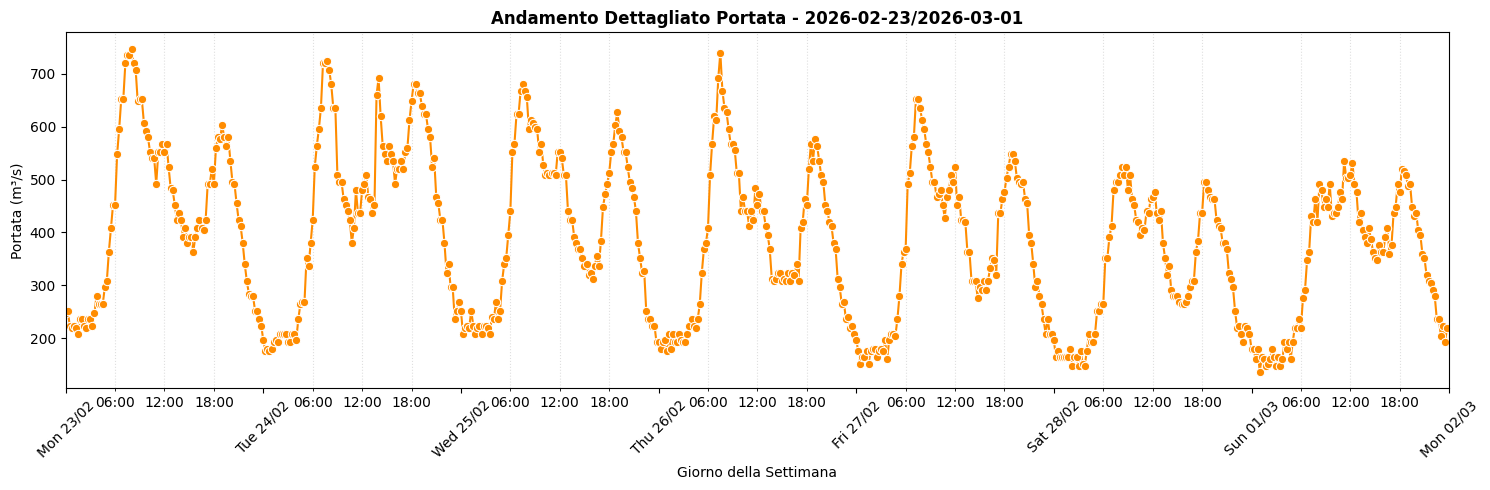

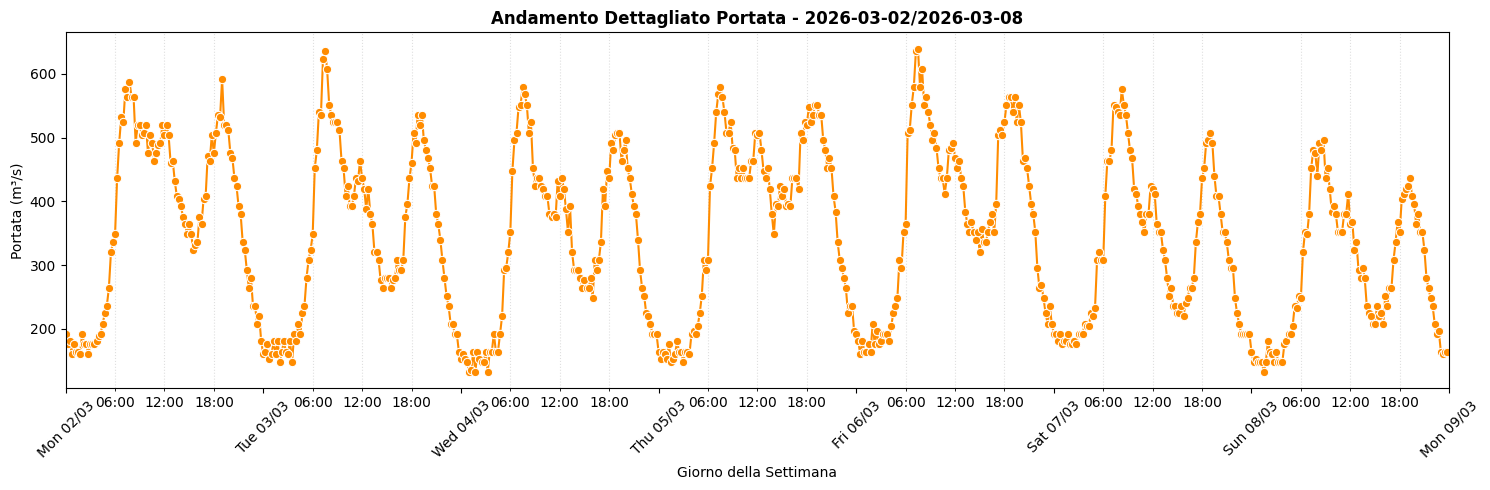

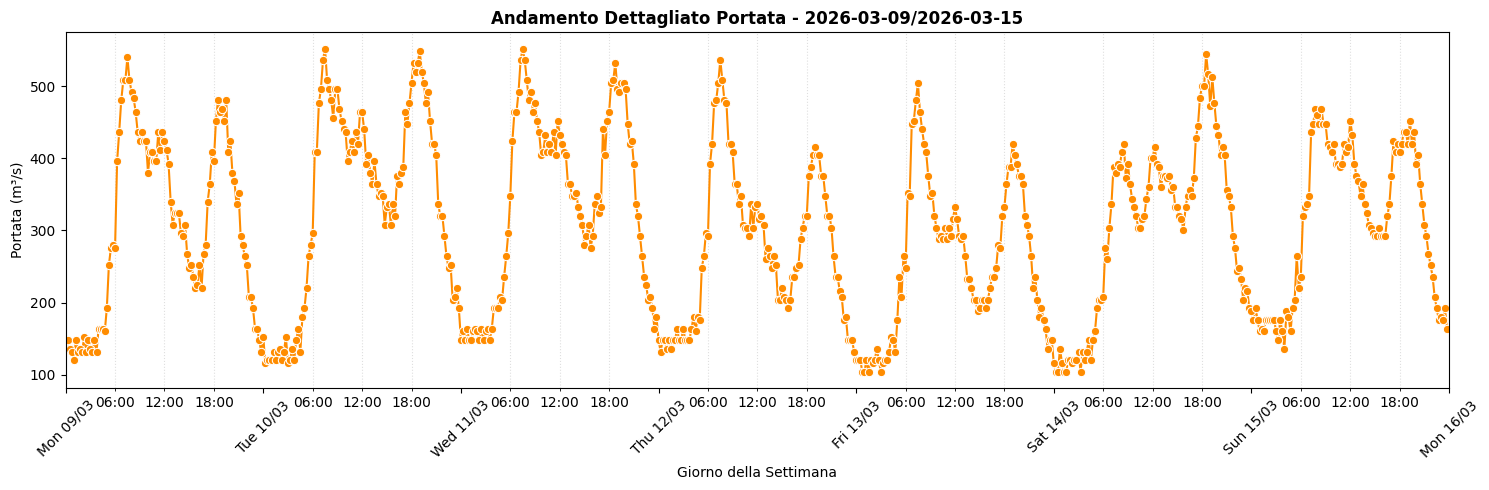

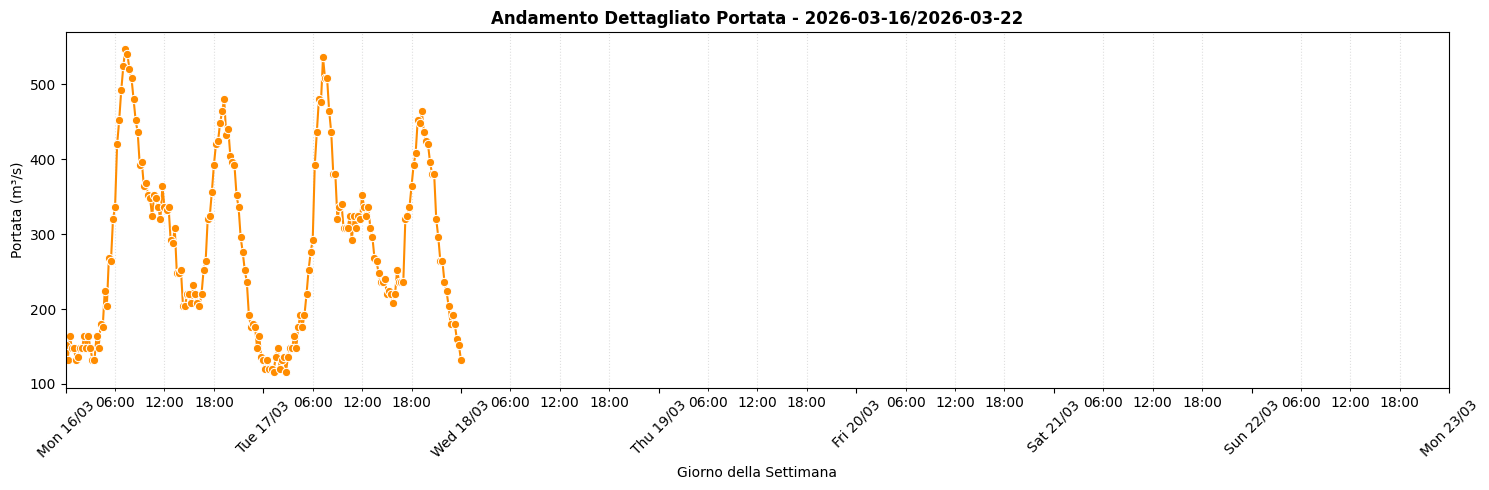

In [4]:
# Aggiungo colonne per settimana e giorno
df_target['settimana'] = df_target['timestamp'].dt.to_period('W').astype(str)
df_target['giorno_nome'] = df_target['timestamp'].dt.day_name()

# Ordino i giorni della settimana
giorni_ordine = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_target['giorno_nome'] = pd.Categorical(df_target['giorno_nome'], categories=giorni_ordine, ordered=True)

# Lista delle settimane uniche
settimane = df_target['settimana'].unique()

# Genero un grafico per ogni settimana
for sett in settimane:
    data_settimana = df_target[df_target['settimana'] == sett]
    
    # --- LOGICA PER SCALA FISSA ---
    # Recuperiamo il lunedì d'inizio della settimana corrente
    start_week = data_settimana['timestamp'].dt.to_period('W').dt.start_time.iloc[0]
    # Calcoliamo la fine (7 giorni dopo)
    end_week = start_week + pd.Timedelta(days=7)

    plt.figure(figsize=(15, 5))
    sns.lineplot(data=data_settimana, x='timestamp', y='portata', marker='o', color='darkorange', linewidth=1.5)
    
    # FORZIAMO L'ASSE X: da lunedì a domenica sera
    plt.xlim(start_week, end_week)
    
    # Formattazione grafica per vedere i giorni chiaramente
    ax = plt.gca()

    # Imposta i segni principali (Tick) sui giorni
    ax.xaxis.set_major_locator(mdates.DayLocator())
    # Formato: Giorno Nome, Giorno/Mese (es. Mon 02/02)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d/%m'))

    # AGGIUNGE LE ORE: Imposta i segni minori (Minor Ticks) ogni 6 ore
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    # Opzionale: mostra l'orario sotto i giorni (formato ridotto)
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))

    # Ruota le etichette per evitare sovrapposizioni
    plt.xticks(rotation=45)

    # Attiva la griglia anche per le ore (opzionale, molto utile)
    plt.grid(True, which='minor', linestyle=':', alpha=0.4)
    
    plt.title(f'Andamento Dettagliato Portata - {sett}', fontweight='bold')
    plt.ylabel('Portata (m³/s)')
    plt.xlabel('Giorno della Settimana')
    plt.xticks(rotation=45)
    plt.tight_layout()
    filename = f"Andamento_Settimanale_{sett.replace('/', '-')}.png"
    plt.savefig(PORTATA_SETTIMANALE_PATH / filename, dpi=300)
    plt.show()
    plt.close()

In [5]:
# 1. Dizionario per la traduzione
mapping_giorni = {
    'Monday': 'Lunedì',
    'Tuesday': 'Martedì',
    'Wednesday': 'Mercoledì',
    'Thursday': 'Giovedì',
    'Friday': 'Venerdì',
    'Saturday': 'Sabato',
    'Sunday': 'Domenica'
}

df_target['giorno'] = df_target['timestamp'].dt.date
giorni = df_target['giorno'].unique()

for giorno in giorni:
    data_giorno = df_target[df_target['giorno'] == giorno].sort_values('timestamp')
    
    start_day = pd.Timestamp(giorno)
    end_day = start_day + pd.Timedelta(days=1)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=data_giorno, x='timestamp', y='portata', marker='o', color='darkorange', linewidth=2)
    
    plt.xlim(start_day, end_day)
    ax = plt.gca()
    
    # Formattazione asse X (Ore)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    plt.grid(True, which='major', linestyle='--', alpha=0.7)
    
    # --- TRADUZIONE E FORMATTAZIONE TITOLO ---
    nome_giorno_en = start_day.day_name()
    nome_giorno_it = mapping_giorni.get(nome_giorno_en, nome_giorno_en)
    data_it = giorno.strftime("%d/%m/%Y") # Formato data italiano
    
    plt.title(f'Andamento Portata - {nome_giorno_it} {data_it}', fontweight='bold')
    plt.ylabel('Portata (m³/s)')
    plt.xlabel('Ora')
    
    plt.tight_layout()
    
    # Salvataggio e chiusura
    filename = f"Portata_Giornaliera_{giorno}.png"
    plt.savefig(PORTATA_GIORNALIERA_PATH / filename, dpi=300)
    plt.close()